# Проект на тему:
### «Анализ факторов увольнений (поиск инсайтов, составление рекомендаций стейкхолдерам)».

Попова В. С.

Группа: DA-127

2026 г.


---





# Подключение библиотек

1. Pandas - это библиотека Python для анализа, обработки и очистки структурированных данных (таблиц).

2. Seaborn - это библиотека Python для визуализации данных и построения статистических графиков.

3. Matplotlib - это библиотека Python для создания двумерных графиков и визуализации данных.

4. NumPy - это библиотека Python для высокопроизводительных математических и численных вычислений.

5. SciPy - это библиотека Python, предназначенная для выполнения научных, инженерных и сложных математических расчетов.

 - команда from scipy import stats импортирует модуль статистики из библиотеки;

 - функция ttest_ind используется для выполнения t-теста Стьюдента;

 - функция chi2_contingency используется для проведения критерия согласия Хи-квадрат Пирсона для таблиц сопряженности.

6. Scikit-Learn (sklearn) — это библиотека Python для классического машинного обучения и интеллектуального анализа данных:

 - функция train_test_split разделяет исходные данные на две изолированные части: для обучения и для тестирования;

 - функция LogisticRegression используется для загрузки алгоритма логистической регрессии;

 - функция StandardScaler используется для масштабирования (нормализации) числовых данных;

 - импорт главных метрик качества для задач классификации: accuracy_score (общая точность), classification_report (текстовый отчет), confusion_matrix (матрица ошибок), roc_curve и roc_auc_score (ROC-анализ);

 - функция RandomForestClassifier используется для создания и обучения модели Случайного леса.

7. Библиотека Imbalanced-learn (сокращенно imblearn) — это официальное расширение для популярного пакета scikit-learn, создана специально для тех случаев, когда одного класса в данных намного больше, чем другого:

- импорт алгоритма SMOTE;

- импорт специализированного ансамблевого классификатора BalancedRandomForestClassifier.






In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

# Подключение источника данных

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
# Просмотр количества непустых значений, типа данных
# Cтатистика по типам данных и объему занимаемой памяти
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Датасет "IBM HR Analytics Employee Attrition & Performance"
содержит 35 столбцов и 1470 строк (сотрудников), данные не имеют пропусков.

Описание полей:

• Age - Возраст сотрудника в годах. Тип данных: int64.

• Attrition - Увольнение сотрудников (Yes/No). Тип данных: object.

• BusinessTravel - Частота командировок (Non-Travel - Нет поездок, Travel_Frequently - Частые поездки, Travel_Rarely - Редкие поездки). Тип данных: object.

• DailyRate - Дневная ставка оплаты. Тип данных: int64.

• Department - Отдел (Human Resources - Персонал, Research & Development - Исследования и разработки, Sales - Продажи). Тип данных: object.

• DistanceFromHome - Расстояние от дома до работы. Тип данных: int64.

• Education - Образование (1-5). 1 - Ниже уровня колледжа, 2 - Колледж, 3 - Бакалавр, 4 - Магистр, 5 - Доктор. Тип данных: int64.

• EducationField - Область образования (Human Resources - Персонал, Life Sciences - Бионаука, Marketing - Маркетинг, Medical - Медицина, Other - Другое, Technical Degree - Техническое образование). Тип данных: object.

• EmployeeCount - Численность сотрудников. Тип данных: int64.

• EmployeeNumber - 	Уникальный идентификационный номер сотрудника. Тип данных: int64.

• EnvironmentSatisfaction - Уровень удовлетворенности рабочей средой (1–4).
1 — Низкий, 2 — Средний, 3 — Высокий, 4 — Очень высокий. Тип данных: int64.

• Gender - 	Пол сотрудника (Male/Female). Тип данных: object.

• HourlyRate - Почасовая ставка оплаты. Тип данных: int64.

• JobInvolvement - 	Степень вовлеченности в работу (1–4). 1 — Низкая, 2 — Средняя, 3 — Высокая, 4 — Очень высокая. Тип данных: int64.

• JobLevel - Уровень должности (грейд) (1-5). Тип данных: int64.

• JobRole - Должность (Healthcare Representative - Медицинский представитель, Human Resources - HR, Laboratory Technician - Лаборант, Manager - Менеджер, Manufacturing Director - Директор по производству, Research Director - Директор по исследованиям, Research Scientist - Ученый-исследователь, Sales Executive - Менеджер по продажам, Sales Representative - Торговый представитель). Тип данных: object.

• JobSatisfaction - Индекс удовлетворенности работой (1–4). 1 — Низкий, 2 — Средний, 3 — Высокий, 4 — Очень высокий. Тип данных: int64.

• MaritalStatus - Семейное положение (Divorced - В разводе, Married - Состоящий в браке, Холост / не замужем - Single). Тип данных: object.

• MonthlyIncome - Ежемесячный доход (зарплата). Тип данных: int64.

• MonthlyRate - Ежемесячная ставка оплаты. Тип данных: int64.

• NumCompaniesWorked - Количество компаний, в которых работал сотрудник. Тип данных: int64.

• Over18 - Старше 18 лет. Тип данных: object.

• OverTime - Наличие переработок (Yes/No). Тип данных: object.

• PercentSalaryHike - Процент повышения заработной платы. Тип данных: int64.

• PerformanceRating - Оценка эффективности сотрудника (3–4). Тип данных: int64.

• RelationshipSatisfaction - Удовлетворенность отношениями (1-4). 1 — Низкая, 2 — Средняя, 3 — Высокая, 4 — Очень высокая. Тип данных: int64.

• StandardHours - Обычный график. Тип данных: int64.

• StockOptionLevel - Уровень владения опционами компании (0-3). Тип данных: int64.

• TotalWorkingYears - 	Общий трудовой стаж сотрудника. Тип данных: int64.

• TrainingTimesLastYear - Время обучения в прошлом году. Тип данных: int64.

• WorkLifeBalance - Оценка баланса между работой и личной жизнью (1–4). 1 — Плохо, 2 — Хорошо, 3 — Лучше, 4 — Идеально. Тип данных: int64.

• YearsAtCompany - 	Количество лет в компании. Тип данных: int64.

• YearsInCurrentRole - 	Количество лет в текущей должности. Тип данных: int64.

• YearsSinceLastPromotion - Количество лет с момента последнего повышения. Тип данных: int64.

• YearsWithCurrManager - Количество лет работы с текущим руководителем. Тип данных: int64.

# Предобработка данных

**Первичное исследование**

In [ ]:
# Просмотр описательной статистики по датасету
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
# Поиск пропусков в датасете и суммирование их по столбцам
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
# Проверка датасета на полные дубликаты строк
df.duplicated().sum()

np.int64(0)

Выполнена проверка датасета на наличие пропущенных значений и полных дубликатов строк. Набор данных является полным: пропуски во всех признаках отсутствуют, повторяющихся записей не обнаружено (в обоих случаях результат равен 0).




**Работа с выбросами и аномалиями**

Все данные проверены на предмет аномалий: построены диаграммы «ящик с усами», сопоставлены отклонения между медианами и средними значениями, рассчитан межквартильный размах (IQR). В результате анализа выявлены основные выбросы по показателям: Monthly income, Total working years, Years at company, Years since last promotion.

Учитывая естественную природу этих отклонений, они сохранены в датасете для дальнейшего обучения прогнозных моделей, так как представляют ключевые группы сотрудников.

In [ ]:
df[['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion']].describe()

,MonthlyIncome,TotalWorkingYears,YearsAtCompany,YearsSinceLastPromotion
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,6502.931293,11.279592,7.008163,2.187755
std,4707.956783,7.780782,6.126525,3.222430
min,1009.000000,0.000000,0.000000,0.000000
25%,2911.000000,6.000000,3.000000,0.000000
50%,4919.000000,10.000000,5.000000,1.000000
75%,8379.000000,15.000000,9.000000,3.000000
max,19999.000000,40.000000,40.000000,15.000000


1. Monthly income (месячный доход)

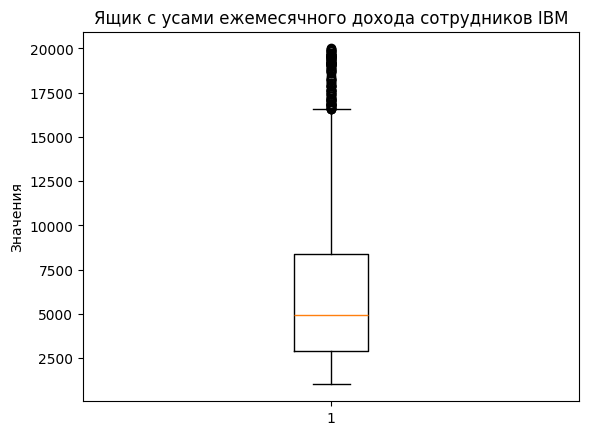

In [ ]:
# Ящик с усами ежемесячного дохода сотрудников IBM
plt.boxplot(df['MonthlyIncome'])
plt.ylabel('Значения')
plt.title('Ящик с усами ежемесячного дохода сотрудников IBM')
plt.show()

Коэффициент 1,5 в связке с IQR (межквартильным размахом) — это стандартный статистический порог для определения выбросов (аномальных значений) в данных.

In [ ]:
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)

# Межквартильный размах
IQR = Q3 - Q1

# Границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, нижняя граница:{lower_bound}, верхняя граница:{upper_bound}')

Q1: 2911.0, Q3: 8379.0, IQR: 5468.0, нижняя граница:-5291.0, верхняя граница:16581.0


**Вывод:** Сотрудники, у которых ежемесячный доход составляет свыше 16 581,00 $ — это статистические выбросы. К ним относятся высокооплачиваемые руководители (Manager, Research Director). Наличие таких выбросов значительно завышает среднюю зарплату по компании, поэтому для оценки реальных доходов сотрудников необходимо ориентироваться на медиану, а не на среднее значение.


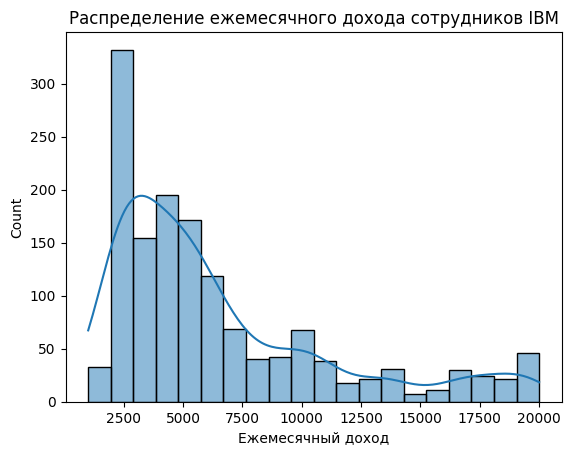

In [ ]:
# Гистограмма плотности распределения ежемесячного дохода сотрудников IBM
sns.histplot(df['MonthlyIncome'], kde = True)
plt.title('Распределение ежемесячного дохода сотрудников IBM')
plt.xlabel('Ежемесячный доход')
plt.show()

In [ ]:
# Асимметрия
df['MonthlyIncome'].skew().round(2)

np.float64(1.37)

**Вывод:** Форма гистограммы плотности распределения визуально близка к логнормальному распределению. Это асимметричная колоколообразная кривая, пик которой смещен влево (в область низких доходов), а длинный "хвост" уходит в правую часть (в область высоких доходов). В этом случае среднее арифметическое находится правее медианы  (Среднее арифметическое = 6 502,93, Медиана = 4 919,00). Коэффициент асимметрии = 1,37.

Минимальный ежемесячный доход сотрудника составляет 1 009,00 $.

Максимальный ежемесячный доход сотрудника составляет 19 999,00 $.

От 1 000,00 до 5 000,00 долларов — это основной интервал заработных плат в компании. Далее уровень заработных плат снижается.


In [ ]:
# Распределение сотрудников по уровню дохода
# Границы интервалов от 1000 до 20000 с шагом 1000
bins = list(range(1000, 21000, 1000))

# Деление данных на интервалы
income_bins = pd.cut(df['MonthlyIncome'], bins = bins)

# Количество сотрудников в каждом интервале и сортировка по порядку
res = income_bins.value_counts().sort_index()

print(res)

MonthlyIncome
(1000, 2000]       33
(2000, 3000]      362
(3000, 4000]      148
(4000, 5000]      206
(5000, 6000]      165
(6000, 7000]      121
(7000, 8000]       54
(8000, 9000]       48
(9000, 10000]      52
(10000, 11000]     66
(11000, 12000]     20
(12000, 13000]     10
(13000, 14000]     43
(14000, 15000]      9
(15000, 16000]      7
(16000, 17000]     29
(17000, 18000]     28
(18000, 19000]     19
(19000, 20000]     50
Name: count, dtype: int64


2. Total working years (общий стаж)

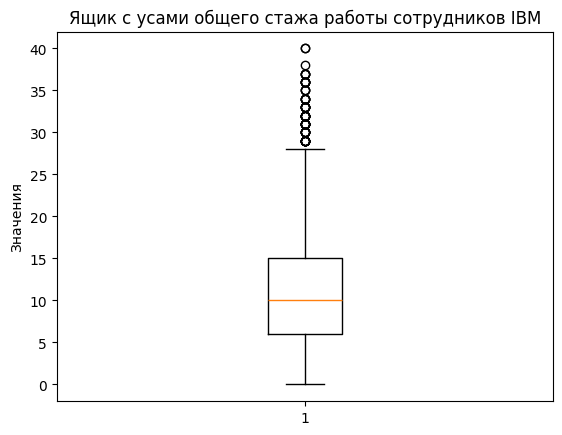

In [ ]:
# Ящик с усами общего стажа работы сотрудников IBM
plt.boxplot(df['TotalWorkingYears'])
plt.ylabel('Значения')
plt.title('Ящик с усами общего стажа работы сотрудников IBM')
plt.show()

In [ ]:
Q1 = df['TotalWorkingYears'].quantile(0.25)
Q3 = df['TotalWorkingYears'].quantile(0.75)

# Межквартильный размах
IQR = Q3 - Q1

# Границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, нижняя граница:{lower_bound}, верхняя граница:{upper_bound}')

Q1: 6.0, Q3: 15.0, IQR: 9.0, нижняя граница:-7.5, верхняя граница:28.5


**Вывод:** Сотрудники, у которых стаж более 28,5 лет - это статистические выбросы. Уникальные специалисты, накопившие опыт, который невозможно быстро передать, являются дефицитным ресурсом. Эта группа практически не подвержена текучести кадров.

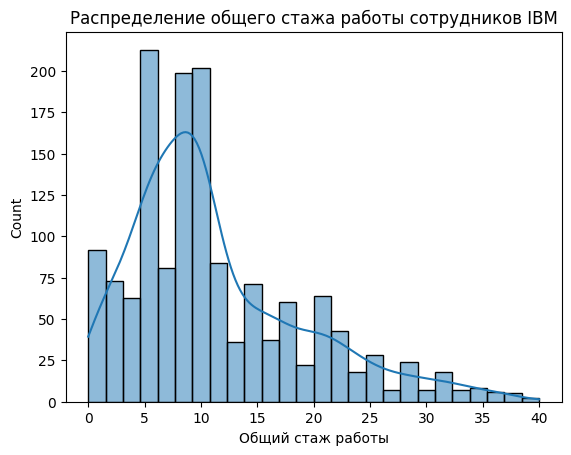

In [ ]:
# Гистограмма плотности распределения общего стажа работы сотрудников IBM
sns.histplot(df['TotalWorkingYears'], kde = True)
plt.title('Распределение общего стажа работы сотрудников IBM')
plt.xlabel('Общий стаж работы')
plt.show()

In [ ]:
# Асимметрия
df['TotalWorkingYears'].skew().round(2)

np.float64(1.12)

**Вывод:** Форма гистограммы плотности распределения визуально близка к логнормальному распределению. Это асимметричная колоколообразная кривая, пик которой смещен влево (в область небольшого стажа), а длинный "хвост" уходит в правую часть. В этом случае среднее арифметическое находится правее медианы (Среднее арифметическое = 11,28, Медиана = 10,00). Коэффициент асимметрии = 1,12.

Минимальное количество лет в компании составляет 0,00 лет.

Максимальное количество лет в компании составляет 40,00 лет.

Самая высокая концентрация данных наблюдается в интервале 0–10 лет (большое количество сотрудников имеет общий стаж до 10 лет).



3. Years at company (количество лет работы сотрудников в компании)

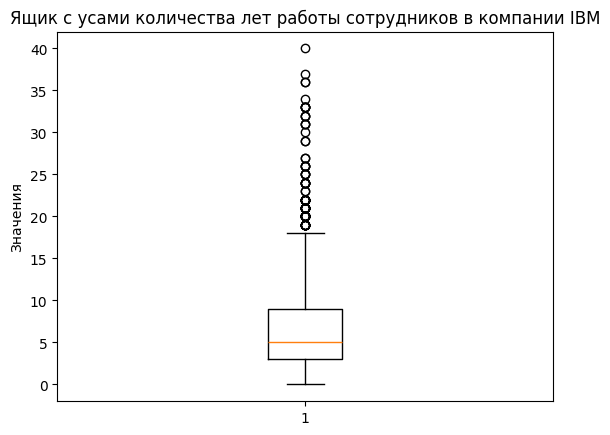

In [ ]:
# Ящик с усами количества лет работы сотрудников в компании IBM
plt.boxplot(df['YearsAtCompany'])
plt.ylabel('Значения')
plt.title('Ящик с усами количества лет работы сотрудников в компании IBM')
plt.show()

In [ ]:
Q1 = df['YearsAtCompany'].quantile(0.25)
Q3 = df['YearsAtCompany'].quantile(0.75)

# Межквартильный размах
IQR = Q3 - Q1

# Границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, нижняя граница:{lower_bound}, верхняя граница:{upper_bound}')

Q1: 3.0, Q3: 9.0, IQR: 6.0, нижняя граница:-6.0, верхняя граница:18.0


**Вывод:** Сотрудники, которые работают в компании более 18 лет — это статистические выбросы. Это наиболее лояльная группа стабильных сотрудников (наставников, опытных специалистов), риск их увольнения очень мал.

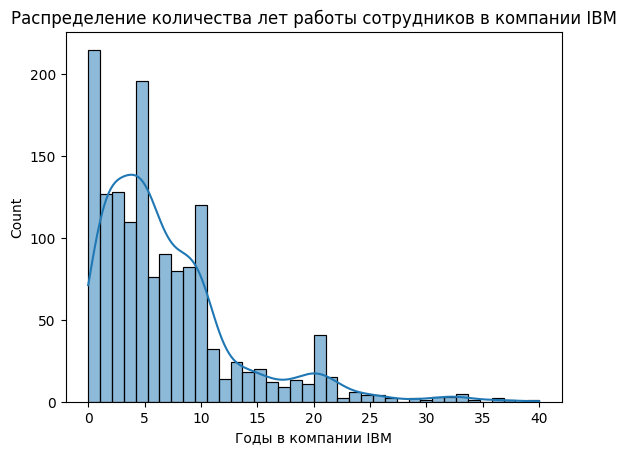

In [ ]:
# Гистограмма плотности распределения количества лет работы сотрудников в компании IBM
sns.histplot(df['YearsAtCompany'], kde = True)
plt.title('Распределение количества лет работы сотрудников в компании IBM')
plt.xlabel('Годы в компании IBM')
plt.show()

In [ ]:
# Асимметрия
df['YearsAtCompany'].skew().round(2)

np.float64(1.76)

**Вывод:** Форма гистограммы плотности распределения визуально близка к логнормальному распределению. Это асимметричная колоколообразная кривая, пик которой смещен влево (в область небольшого стажа в компании), а длинный "хвост" уходит в правую часть. В этом случае среднее арифметическое находится правее медианы  (Среднее арифметическое = 7,01, Медиана = 5,00). Коэффициент асимметрии = 1,76.

Минимальное количество лет в компании составляет 0,00 лет.

Максимальное количество лет в компании составляет 40,00 лет.

Самая высокая концентрация данных наблюдается в интервале 0–10 лет (особенно большое количество сотрудников работает в компании до 5 лет).

4. Years since last promotion (количество лет с момента последнего повышения сотрудников)

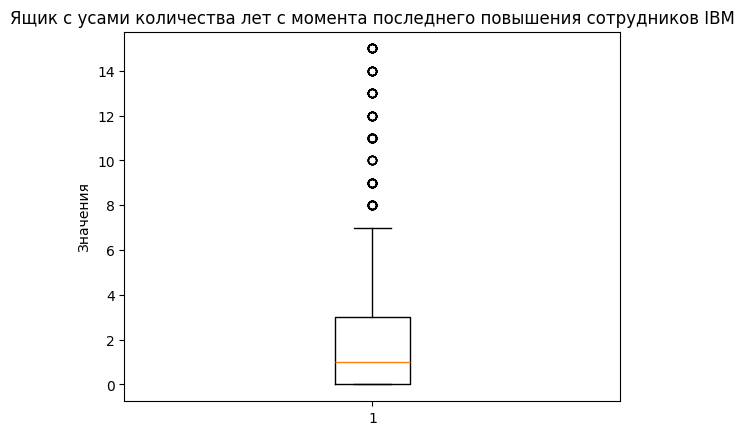

In [ ]:
# Ящик с усами количества лет с момента последнего повышения сотрудников IBM
plt.boxplot(df['YearsSinceLastPromotion'])
plt.ylabel('Значения')
plt.title('Ящик с усами количества лет с момента последнего повышения сотрудников IBM')
plt.show()

In [ ]:
Q1 = df['YearsSinceLastPromotion'].quantile(0.25)
Q3 = df['YearsSinceLastPromotion'].quantile(0.75)

# Межквартильный размах
IQR = Q3 - Q1

# Границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, нижняя граница:{lower_bound}, верхняя граница:{upper_bound}')

Q1: 0.0, Q3: 3.0, IQR: 3.0, нижняя граница:-4.5, верхняя граница:7.5


**Вывод:** Сотрудники, которых не повышали более 7,5 лет — это статистические выбросы. В масштабах HR-стратегии их нельзя рассматривать как общую массу, стандартные методы мотивации для них неэффективны и к ним требуется индивидуальный подход. Длительный карьерный застой может стать прямой причиной увольнения или признаком профессионального выгорания.


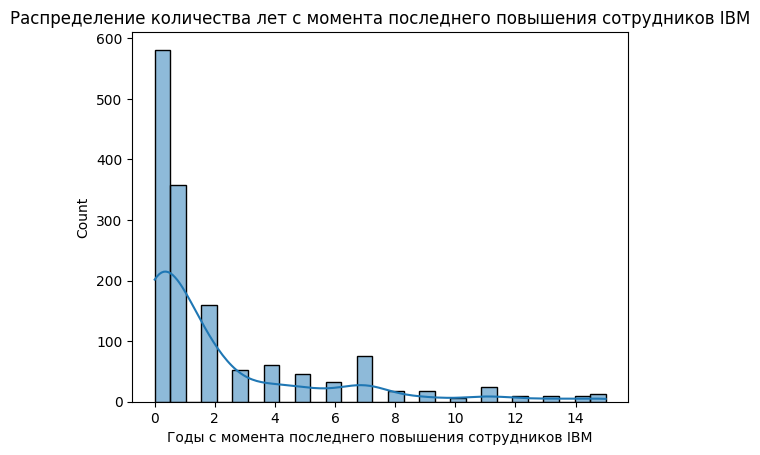

In [ ]:
# Гистограмма плотности распределения количества лет с момента последнего повышения сотрудников IBM
sns.histplot(df['YearsSinceLastPromotion'], kde = True)
plt.title('Распределение количества лет с момента последнего повышения сотрудников IBM')
plt.xlabel('Годы с момента последнего повышения сотрудников IBM')
plt.show()

In [ ]:
# Асимметрия
df['YearsSinceLastPromotion'].skew().round(2)

np.float64(1.98)

**Вывод:** Форма гистограммы плотности распределения визуально близка к логнормальному распределению. Это асимметричная колоколообразная кривая, пик которой смещен влево (в область минимального времени ожидания), а длинный "хвост" уходит в правую часть. В этом случае среднее арифметическое находится правее медианы  (Среднее арифметическое = 2,19, Медиана = 1,00). Коэффициент асимметрии = 1,98.

Минимальное количество лет с момента последнего повышения сотрудников составляет 0,00 лет.

Максимальное количество лет с момента последнего повышения сотрудников составляет 15,00 лет.

Самая высокая концентрация данных наблюдается в интервале 0–2 лет. Это означает, что большинство сотрудников в компании получают повышение регулярно. Компания старается поддерживать динамику роста.

На гистограмме плотности "хвост" после 7,5 лет выглядит почти плоским.

**Предобработка данных**

In [ ]:
# Удаление неинформативных столбцов
df_new = df.drop(columns = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'])
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

Выполнено кодирование категориальных переменных в числовые форматы для обеспечения возможности их обработки алгоритмами машинного обучения и для статистического анализа. Бинарные переменные (Attrition, Overtime, Gender) преобразованы с помощью логической замены (1/0). Для признаков с выраженной иерархией (BusinessTravel) применено порядковое кодирование, а для номинальных данных (Department, EducationField, JobRole, MaritalStatus) — присвоение числовых идентификаторов.

In [ ]:
# Преобразование бинарных признаков в числовые форматы
# Добавление столбца - увольнения (целевая переменная)
df_new['Attrition_new'] = df_new['Attrition'].map({'Yes': 1, 'No': 0})
# print(df_new[['Attrition', 'Attrition_new']])

# Добавление столбца - сверхурочная работа
df_new['Overtime_new'] = df_new['OverTime'].map({'Yes': 1, 'No': 0})
# print(df_new[['OverTime', 'Overtime_new']])

# Добавление столбца - пол
df_new['Gender_new'] = df_new['Gender'].map({'Male': 1, 'Female': 0})
# print(df_new[['Gender', 'Gender_new']])

df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [ ]:
# Преобразование категориальных признаков в числовые форматы
# Добавление столбца - командировки
df_new['BusinessTravel_new'] = df_new['BusinessTravel'].map({'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2})
# print(df_new[['BusinessTravel', 'BusinessTravel_new']])

# Добавление столбца - отделы
df_new['Department_new'] = df_new['Department'].map({'Human Resources': 1, 'Research & Development': 2, 'Sales': 3})
# print(df_new[['Department', 'Department_new']])

# Добавление столбца - область образования
df_new['EducationField_new'] = df_new['EducationField'].map({'Human Resources': 1, 'Life Sciences': 2, 'Marketing': 3, 'Medical': 4, 'Other': 5, 'Technical Degree': 6})
# print(df_new[['EducationField', 'EducationField_new']])

# Добавление столбца - должность
df_new['JobRole_new'] = df_new['JobRole'].map({'Healthcare Representative': 1, 'Human Resources': 2, 'Laboratory Technician': 3, 'Manager': 4, 'Manufacturing Director': 5, 'Research Director': 6, 'Research Scientist': 7, 'Sales Executive': 8, 'Sales Representative': 9})
# print(df_new[['JobRole', 'JobRole_new']])

# Добавление столбца - cемейное положение
df_new['MaritalStatus_new'] = df_new['MaritalStatus'].map({'Divorced': 1, 'Married': 2, 'Single': 3})
# print(df_new[['MaritalStatus', 'MaritalStatus_new']])

df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

# Анализ данных

**Коэффициент текучести по всей компании IBM**

In [ ]:
# Расчет коэффициента текучести по всей компании (в процентах)
# Количество уволившихся сотрудников за период / численность сотрудников (принято брать среднесписочную за тот же срок) x 100%
print((df_new['Attrition'].value_counts(normalize = True)['Yes'] * 100).round(2))

16.12


**Описательная статистика**

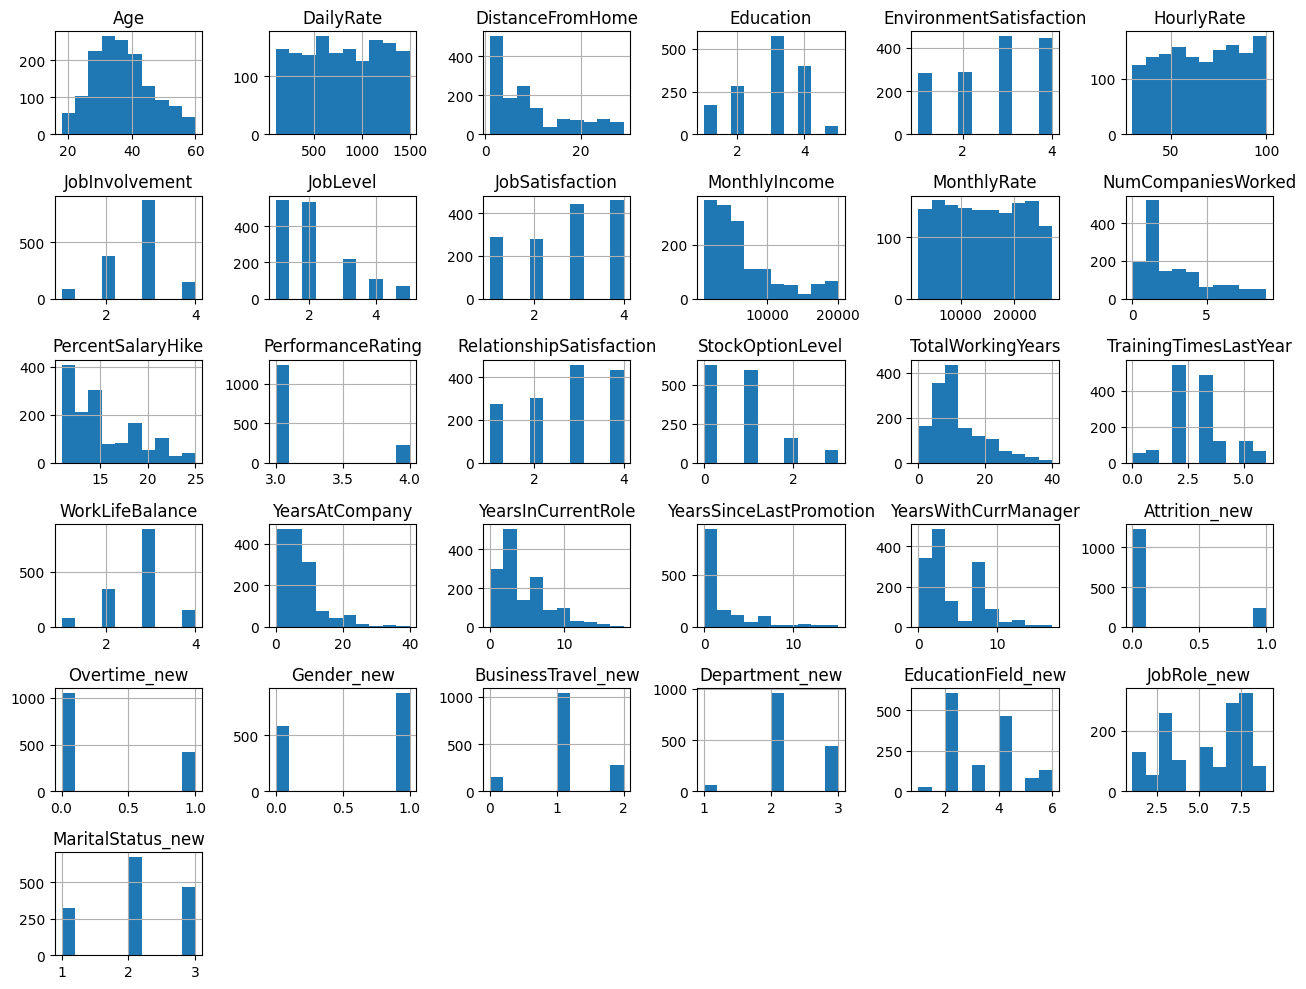

In [ ]:
# Гистограммы плотности распределения признаков
num_cols = df_new.select_dtypes(include = np.number).columns

df_new[num_cols].hist(figsize = (13, 10))
plt.tight_layout()
plt.show()

1. Age (возраст)

In [ ]:
df_new['Age'].describe()

,Age
count,1470.000000
mean,36.923810
std,9.135373
min,18.000000
25%,30.000000
50%,36.000000
75%,43.000000
max,60.000000


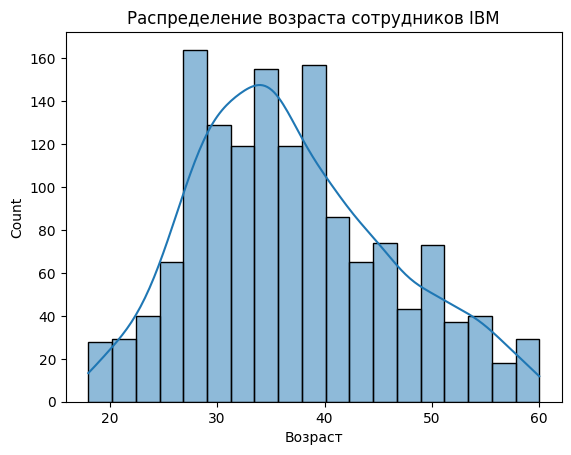

In [ ]:
# Гистограмма плотности распределения возраста сотрудников
sns.histplot(df_new['Age'], kde = True)
plt.title('Распределение возраста сотрудников IBM')
plt.xlabel('Возраст')
plt.show()

In [ ]:
# Асимметрия
df_new['Age'].skew().round(2)

np.float64(0.41)

**Вывод:** Форма гистограммы плотности распределения симметричная колоколообразная с пиком по середине указывает на нормальное распределение (Среднее арифметическое 36,92 приблизительно равно Медиане 36,00).

Минимальный возраст сотрудника составляет 18,00 лет.

Максимальный возраст сотрудника составляет 60,00 лет.

Средний возраст сотрудника составляет 36,92 лет.

Стандартное отклонение: отклонение от среднего значения 36,92 лет составляет 9,14 лет.

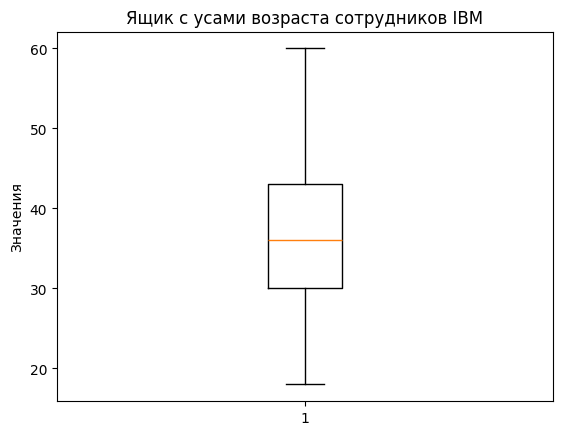

In [ ]:
# Ящик с усами возраста сотрудников IBM
plt.boxplot(df_new['Age'])
plt.ylabel('Значения')
plt.title('Ящик с усами возраста сотрудников IBM')
plt.show()

**Вывод:** Данные не имеют ярко выраженных выбросов.

2. Years with current manager (количество лет работы с текущим руководителем)

In [ ]:
df_new['YearsWithCurrManager'].describe()

,YearsWithCurrManager
count,1470.000000
mean,4.123129
std,3.568136
min,0.000000
25%,2.000000
50%,3.000000
75%,7.000000
max,17.000000


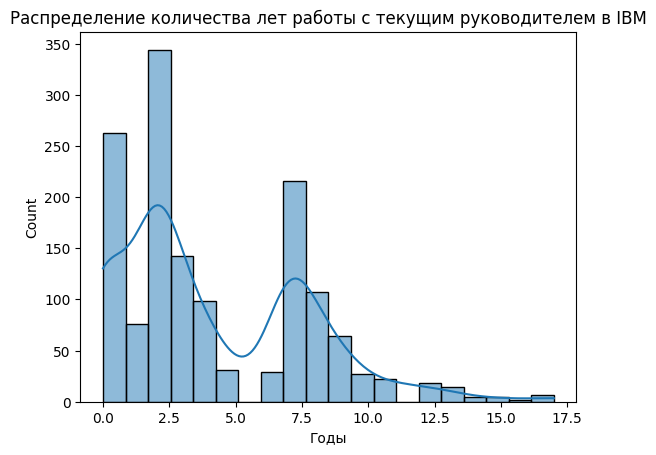

In [ ]:
# Гистограмма плотности распределения количества лет работы с текущим руководителем в IBM
sns.histplot(df_new['YearsWithCurrManager'], kde = True)
plt.title('Распределение количества лет работы с текущим руководителем в IBM')
plt.xlabel('Годы')
plt.show()

In [ ]:
# Асимметрия
df_new['YearsWithCurrManager'].skew().round(2)

np.float64(0.83)

**Вывод:** Форма гистограммы плотности распределения визуально близка к логнормальному распределению. Это асимметричная колоколообразная кривая, обладающая свойством мультимодальности и имеющая два пика: основной (в интервале 0–3 года) и дополнительный (в интервале 7–8 лет), а  также длинный "хвост", уходящий в правую часть. В этом случае среднее арифметическое находится правее медианы (Среднее арифметическое = 4,12, Медиана = 3,00). Коэффициент асимметрии = 0,83.

Минимальное количество лет работы с текущим руководителем составляет 0,00 лет.

Максимальное количество лет работы с текущим руководителем составляет 17,00 лет.

Самая высокая концентрация данных наблюдается в интервале 0–3 лет, высокая доля "новых" сотрудников. Это означает, что большинство сотрудников в компании работают с одним руководителем недолго. Далее на графике можно увидеть снижение количества сотрудников до 7-8 лет, после этого периода снова снижение.




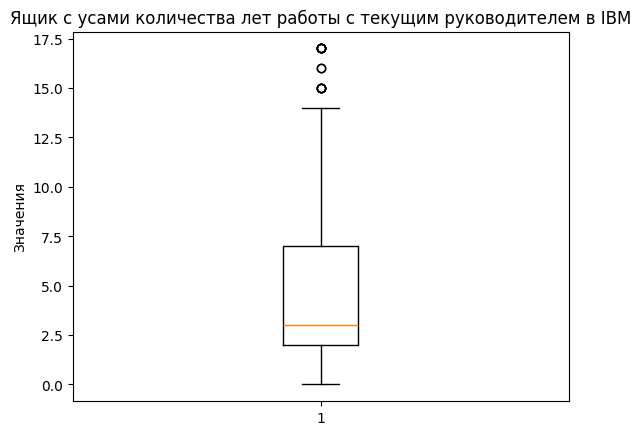

In [ ]:
# Ящик с усами количества лет работы с текущим руководителем в IBM
plt.boxplot(df_new['YearsWithCurrManager'])
plt.ylabel('Значения')
plt.title('Ящик с усами количества лет работы с текущим руководителем в IBM')
plt.show()

In [ ]:
Q1 = df_new['YearsWithCurrManager'].quantile(0.25)
Q3 = df_new['YearsWithCurrManager'].quantile(0.75)

# Межквартильный размах
IQR = Q3 - Q1

# Границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, нижняя граница:{lower_bound}, верхняя граница:{upper_bound}')

Q1: 2.0, Q3: 7.0, IQR: 5.0, нижняя граница:-5.5, верхняя граница:14.5


**Вывод:** Сотрудники, работающие с одним и тем же руководителем более 14,5 лет, являются редким исключением (выбросами). Скорее всего это "старые" сотрудники, которых устраивают условия труда и руководитель, стабильность в компании.

**Анализ распределения целевой переменной**

Attrition (увольнение)

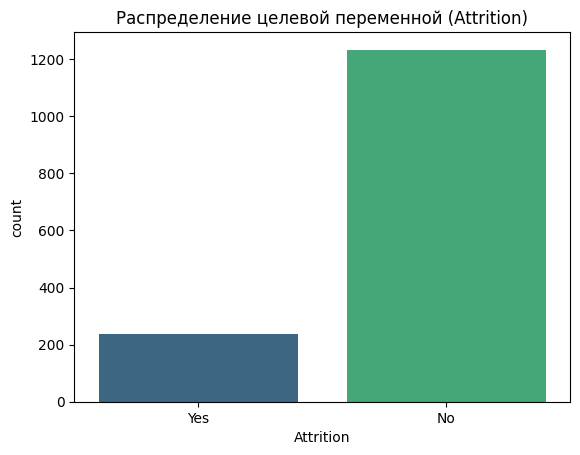

,Количество,"Проценты, %"
Attrition,,
No,1233,83.88
Yes,237,16.12


In [ ]:
# График распределения целевой переменной 'Attrition'
sns.countplot(x = 'Attrition', hue = 'Attrition', data = df_new, palette = 'viridis', legend = False)
plt.title('Распределение целевой переменной (Attrition)')
plt.show()

sum_attrition = pd.DataFrame({
    'Количество': df_new['Attrition'].value_counts(),
    'Проценты, %': (df_new['Attrition'].value_counts(normalize = True) * 100).round(2)
    })

sum_attrition

**Вывод:** Работающие сотрудники - 1233 чел. (83,88%), уволенные сотрудники - 237 чел. (16,12%). Следовательно, мы имеем дело с проблемой несбалансированного класса.

**Сравнительный анализ**

1. Over time (переработки)

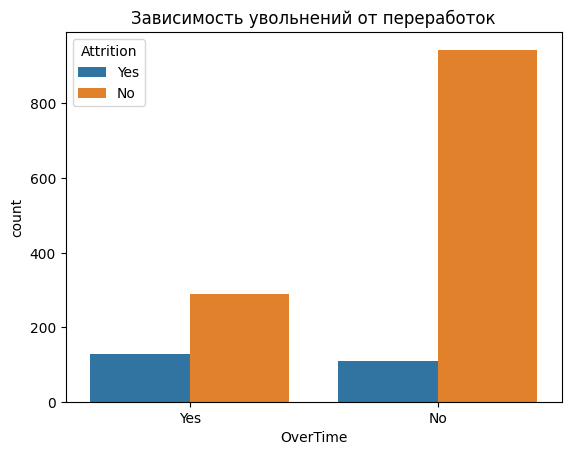

Количество  Проценты, %
Attrition OverTime                         
No        No               944        64.22
          Yes              289        19.66
Yes       Yes              127         8.64
          No               110         7.48

In [ ]:
# График зависимости целевой переменной 'Attrition' от переменной 'OverTime'
sns.countplot(data = df_new, x = 'OverTime', hue = 'Attrition')
plt.title('Зависимость увольнений от переработок')
plt.show()

sum_overtime = pd.DataFrame({
    'Количество': df_new[['Attrition', 'OverTime']].value_counts(),
    'Проценты, %': (df_new[['Attrition', 'OverTime']].value_counts(normalize = True) * 100).round(2)
    })

sum_overtime

**Вывод:** Уволилось 127 сотрудников, работающих сверхурочно. Уровень увольнений среди сотрудников, работающих сверхурочно, составляет 30,5 % (127 / (127+289) * 100), что почти в 3 раза выше, чем у тех, кто не работает сверхурочно - 10,4 % (110 / (110 + 944) * 100).

2. Marital status (семейное положение)

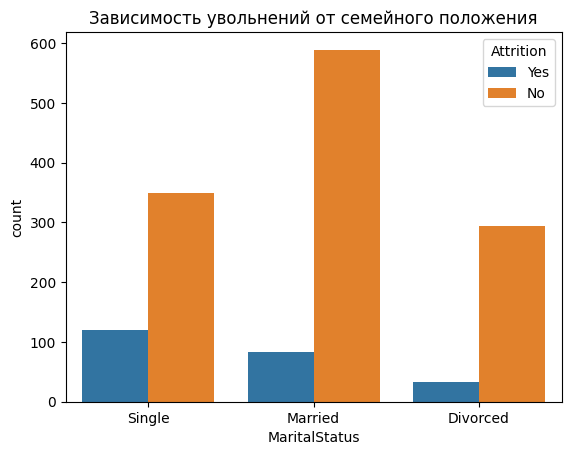

Количество  Проценты, %
Attrition MaritalStatus                         
No        Married               589        40.07
          Single                350        23.81
          Divorced              294        20.00
Yes       Single                120         8.16
          Married                84         5.71
          Divorced               33         2.24

In [ ]:
# График зависимости целевой переменной 'Attrition' от переменной 'MaritalStatus'
sns.countplot(data = df_new, x = 'MaritalStatus', hue = 'Attrition')
plt.title('Зависимость увольнений от семейного положения')
plt.show()

sum_maritalstatus = pd.DataFrame({
    'Количество': df_new[['Attrition', 'MaritalStatus']].value_counts(),
    'Проценты, %': (df_new[['Attrition', 'MaritalStatus']].value_counts(normalize = True) * 100).round(2)
    })

sum_maritalstatus

**Вывод:** Уволилось 120 сотрудников со статусом Single (холост / не замужем). Одинокие сотрудники увольняются чаще, уровень оттока составляет 26 %  (120 / (120 + 350) * 100). Это объясняется отсутствием семейных обязательств, что делает их более мобильными и готовыми к смене работы ради карьеры или смене обстановки.

3. Stock option level (уровень опционов)

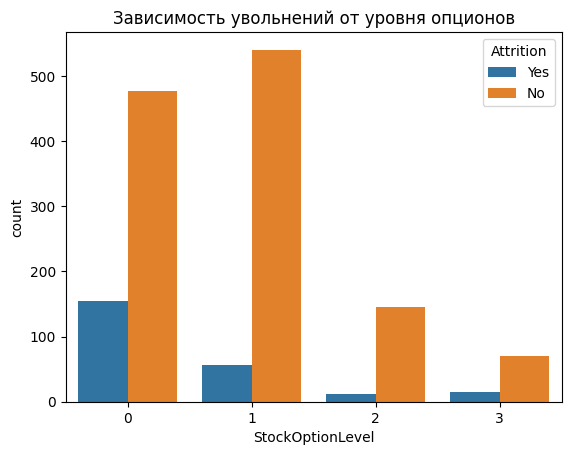

Количество  Проценты, %
Attrition StockOptionLevel                         
No        1                        540        36.73
          0                        477        32.45
Yes       0                        154        10.48
No        2                        146         9.93
          3                         70         4.76
Yes       1                         56         3.81
          3                         15         1.02
          2                         12         0.82

In [ ]:
# График зависимости целевой переменной 'Attrition' от переменной 'StockOptionLevel'
sns.countplot(data = df_new, x = 'StockOptionLevel', hue = 'Attrition')
plt.title("Зависимость увольнений от уровня опционов")
plt.show()

sum_stockoptionlevel = pd.DataFrame({
    'Количество': df_new[['Attrition', 'StockOptionLevel']].value_counts(),
    'Проценты, %': (df_new[['Attrition', 'StockOptionLevel']].value_counts(normalize = True) * 100).round(2)
    })

sum_stockoptionlevel

**Вывод:** Самый высокий уровень увольнений наблюдается у сотрудников, не имеющих опционов (уровень = 0) - 154 сотрудника. Не имея накопленных долгосрочных активов в компании, они легче принимают решение об уходе, в то время как наличие акций удерживает ключевых сотрудников.


4. Job role (должность)

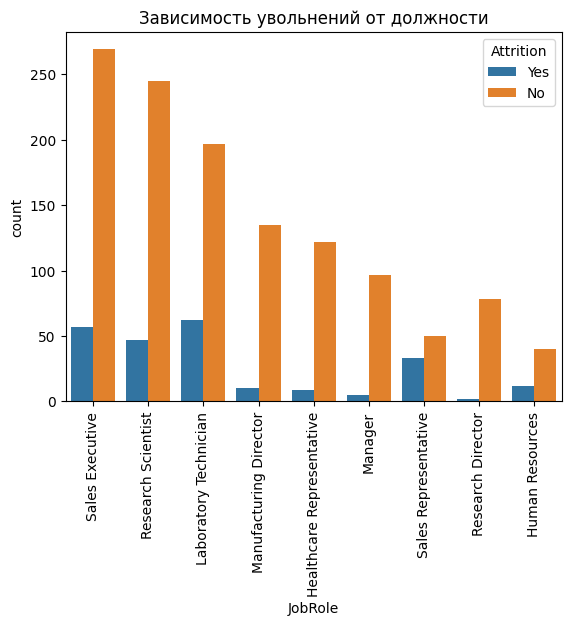

Количество  Проценты, %
Attrition JobRole                                           
No        Sales Executive                   269        18.30
          Research Scientist                245        16.67
          Laboratory Technician             197        13.40
          Manufacturing Director            135         9.18
          Healthcare Representative         122         8.30
          Manager                            97         6.60
          Research Director                  78         5.31
Yes       Laboratory Technician              62         4.22
          Sales Executive                    57         3.88
No        Sales Representative               50         3.40
Yes       Research Scientist                 47         3.20
No        Human Resources                    40         2.72
Yes       Sales Representative               33         2.24
          Human Resources                    12         0.82
          Manufacturing Director             10         0.68
          Healthcare Representative           9         0.61
          Manager                             5         0.34
          Research Director                   2         0.14

In [ ]:
# График зависимости целевой переменной 'Attrition' от переменной 'JobRole'
sns.countplot(data = df_new, x = 'JobRole', hue = 'Attrition')
plt.title("Зависимость увольнений от должности")
plt.xticks(rotation=90)
plt.show()

sum_jobrole = pd.DataFrame({
    'Количество': df_new[['Attrition', 'JobRole']].value_counts(),
    'Проценты, %': (df_new[['Attrition', 'JobRole']].value_counts(normalize = True) * 100).round(2)
    })

sum_jobrole

**Вывод:** Проанализировав отток по должностям, видно, что большая часть сотрудников увольнялась с должности Laboratory Technician (лаборант) - 62 чел. из отдела Research & Development (Исследования и разработки); с должности Sales Executive (менеджер по продажам) - 57 чел. из отдела Sales (Продажи); с должности Research Scientist (ученый-исследователь) - 47 чел. из отдела Research & Development (Исследования и разработки). Общий отток сотрудников происходит из отдела Research & Development (Исследования и разработки). В то же время руководящий состав (Manager, Manufacturing Director, Research Director) остается наиболее стабильным звеном компании, что подтверждает эффективность текущей системы мотивации для топ-менеджмента.


5. Age (возраст)

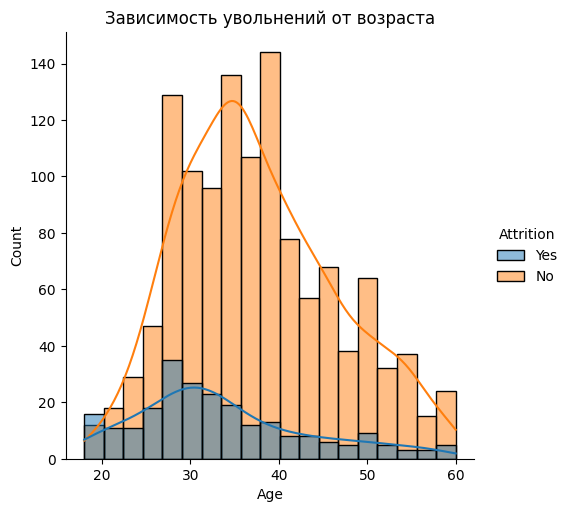

In [ ]:
# График зависимости целевой переменной 'Attrition' от переменной 'Age'
sns.displot(data = df_new, x = 'Age', hue = 'Attrition', kde = True)
plt.title("Зависимость увольнений от возраста")
plt.show()

**Вывод:** Молодые сотрудники (до 31 года) увольняются чаще. Скорее всего это стажеры, либо временные сотрудники, которые изначально не планируют оставаться в компании на длительный срок. Это указывает на то, что компания является для них «стартовой площадкой».

6. Years with current manager (количество лет работы с текущим руководителем)

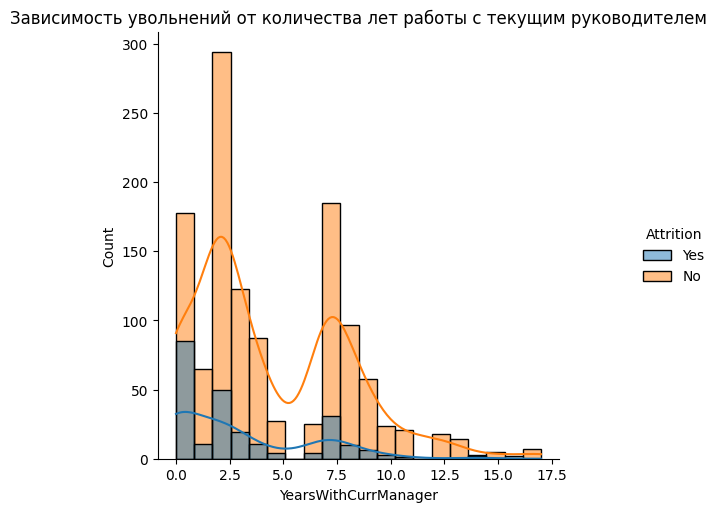

In [ ]:
# График зависимости целевой переменной 'Attrition' от переменной 'YearsWithCurrManager'
sns.displot(data = df_new, x = 'YearsWithCurrManager', hue = 'Attrition', kde = True)
plt.title("Зависимость увольнений от количества лет работы с текущим руководителем")
plt.show()

**Вывод:** Сотрудники увольняются чаще всего в первые два года работы с новым руководителем. После 7 лет количество увольнений снижается с увеличением срока совместной работы. Стабильность отношений с руководителем напрямую снижает риск увольнения.


7. Monthly income (месячный доход)

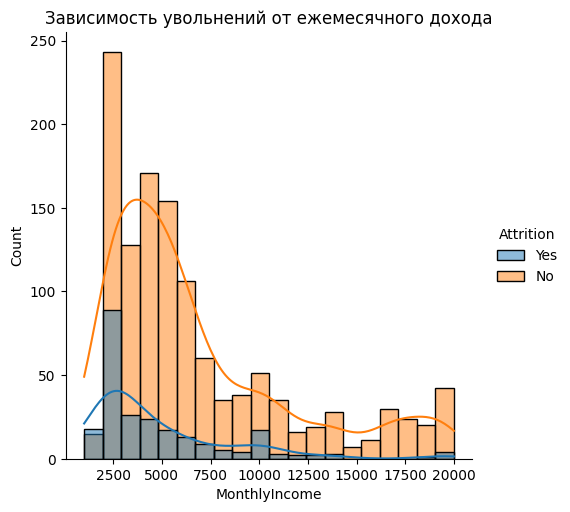

In [ ]:
# График зависимости целевой переменной 'Attrition' от переменной 'MonthlyIncome'
sns.displot(data = df_new, x = 'MonthlyIncome', hue = 'Attrition', kde = True)
plt.title("Зависимость увольнений от ежемесячного дохода")
plt.show()

**Вывод:** Основная масса увольнений находится в интервале ежемесячных доходов от 1 009 до 4 969 долларов. Сотрудники с низкой оплатой труда чаще покидают компанию. Далее частота увольнений снижается, а после 10 854 долларов увольнения становятся единичными случаями. Это подтверждает, что высокий доход является одним из самых эффективных инструментов удержания кадров.

8. Total working years (общий стаж)

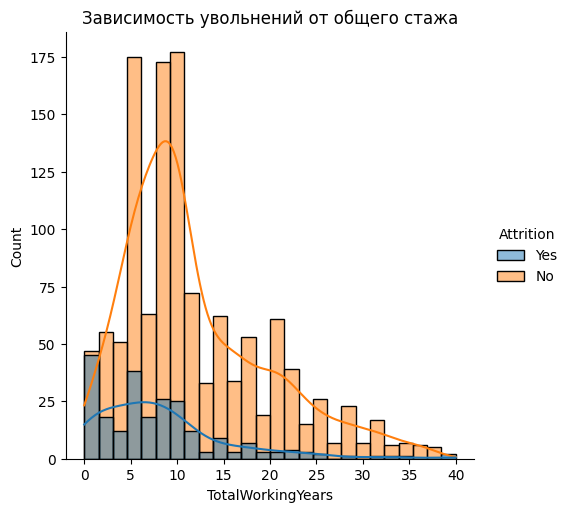

In [ ]:
# График зависимости целевой переменной 'Attrition' от переменной 'TotalWorkingYears'
sns.displot(data = df_new, x = 'TotalWorkingYears', hue = 'Attrition', kde = True)
plt.title("Зависимость увольнений от общего стажа")
plt.show()

**Вывод:** Сотрудники, проработавшие до 6 лет, увольняются чаще. После 10 лет общего стажа работы интенсивность оттока сотрудников существенно снижается, остаются опытные специалисты. Общий трудовой стаж напрямую влияет на устойчивость кадров.

**Корреляции**

Проверены значения коэффициентов корреляции Пирсона всех данных датасета, влияющих на увольнение, с помощью тепловой матрицы. Ниже приведены основные важные факторы.

<Axes: >

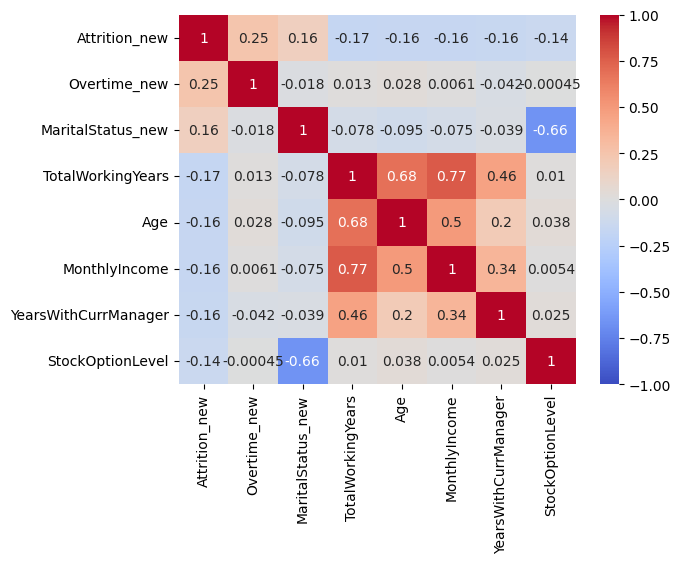

In [ ]:
# Матрица корреляции средствами визуализации seaborn (тепловая матрица)
# Основные факторы, влияющие на увольнение ('Attrition_new')
sns.heatmap(df_new[['Attrition_new', 'Overtime_new', 'MaritalStatus_new', 'TotalWorkingYears', 'Age', 'MonthlyIncome', 'YearsWithCurrManager', 'StockOptionLevel']].corr(), annot = True, vmin=-1, vmax=1, center= 0, cmap= 'coolwarm')

In [ ]:
# Корреляция увольнений к переработкам
df_new['Attrition_new'].corr(df_new['Overtime_new'])

np.float64(0.24611799424580322)

In [ ]:
# Корреляция увольнений к семейному положению
df_new['Attrition_new'].corr(df_new['MaritalStatus_new'])

np.float64(0.1620702346570142)

In [ ]:
# Корреляция увольнений к общему стажу
df_new['Attrition_new'].corr(df_new['TotalWorkingYears'])

np.float64(-0.17106324613622623)

In [ ]:
# Корреляция увольнений к возрасту
df_new['Attrition_new'].corr(df_new['Age'])

np.float64(-0.15920500686577926)

In [ ]:
# Корреляция увольнений к месячному доходу
df_new['Attrition_new'].corr(df_new['MonthlyIncome'])

np.float64(-0.15983958238498835)

In [ ]:
# Корреляция увольнений к количеству лет работы с текущим руководителем
df_new['Attrition_new'].corr(df_new['YearsWithCurrManager'])

np.float64(-0.15619931590162844)

In [ ]:
# Корреляция увольнений к уровню опционов
df_new['Attrition_new'].corr(df_new['StockOptionLevel'])

np.float64(-0.1371449189333258)

**Вывод:**

1. Over time (переработки): положительный коэффициент корреляции = 0,25. Означает очень слабую положительную связь, рост сверхурочных приводит к росту увольнений. Самый ключевой фактор.
2. Marital status (семейное положение): положительный коэффициент корреляции = 0,16. Означает очень слабую положительную связь, одинокие сотрудники (Single) увольняются чаще, чем состоящие в браке или разведенные.
3. Total working years (общий стаж): отрицательный коэффициент корреляции = - 0,17. Означает очень слабую обратную связь, чем меньше стаж, тем больше вероятность увольнения.
4. Age (возраст): отрицательный коэффициент корреляции = - 0,16. Означает очень слабую обратную связь, чем меньше возраст, тем больше вероятность увольнения.
5. Monthly income (месячный доход): отрицательный коэффициент корреляции = - 0,16. Означает очень слабую обратную связь, чем меньше заработная плата у сотрудника, тем больше вероятность увольнения.
6. Years with current manager (количество лет работы с текущим руководителем): отрицательный коэффициент корреляции = - 0,16. Означает очень слабую обратную связь, чем меньше сотрудник проработал с текущим руководителем, тем больше вероятность увольнения.
7. Stock option level (уровень опционов): отрицательный коэффициент корреляции = - 0,14. Означает очень слабую обратную связь, чем меньше акций у сотрудника (или их нет), тем больше вероятность увольнения. Сотрудники не чувствуют себя совладельцами бизнеса и не демонстрируют гораздо более высокую привязанность к компании.

**Статистические гипотезы**

In [ ]:
#  Формирование выборок по увольнениям
df_new1 = df_new[df_new['Attrition'] == 'Yes']
df_new2 = df_new[df_new['Attrition'] == 'No']

print(f'Выборки не имеют одинаковую длину: {len(df_new1) != len(df_new2)}')

Выборки не имеют одинаковую длину: True


In [ ]:
# Уровень значимости
alpha = 0.05

**1. Гипотеза:** Молодые сотрудники увольняются чаще.

In [ ]:
# Проводим тест Левена для проверки равенства (однородности) дисперсий в двух группах
stat, p_value = stats.levene(df_new1['Age'], df_new2['Age'])

print(f"p-value теста Левена: {p_value}")

if p_value > 0.05:
    print("Дисперсии равны.")
else:
    print("Дисперсии не равны.")

p-value теста Левена: 0.4849988830829256
Дисперсии равны.


Для проверки гипотезы использован t-критерий Стьюдента — параметрический статистический метод для определения значимости различий между средними значениями в двух независимых группах.
Все ключевые условия применимости критерия соблюдены:
 - распределение выборочных средних в каждой группе приблизительно соответствует нормальному закону распределения;
 - разброс данных (дисперсия) в обеих сравниваемых группах примерно одинаков;
  - данные независимы.

In [ ]:
# Проведение двухвыборочного t-теста (t-критерий Стьюдента) для независимых выборок
# df_new1['Age'] — уволившиеся, df_new2['Age'] — оставшиеся
result = ttest_ind(df_new1['Age'], df_new2['Age'])
print('p-value: %.8f' % result.pvalue)

# Н0: Нет разницы в среднем возрасте двух групп
# Н1: Существует разница в среднем возрасте обеих групп
if (result.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 0.00000000
Отвергаем нулевую гипотезу


**Вывод:** Отвергаем нулевую гипотезу H0. Между средним возрастом уволившихся и оставшихся сотрудников существует статистически значимая разница.

In [ ]:
# Расчет средних возрастов в группах
print(f"Средний возраст уволившихся: {df_new1['Age'].mean():.1f} лет")
print(f"Средний возраст оставшихся: {df_new2['Age'].mean():.1f} лет")

Средний возраст уволившихся: 33.6 лет
Средний возраст оставшихся: 37.6 лет


**Вывод:** Это говорит о том, что молодые сотрудники (в среднем) с большей вероятностью уходят из компании, в то время как старшие сотрудники обычно остаются.

**2. Гипотеза:** Сотрудники, работающие сверхурочно, увольняются чаще.

Для проверки гипотезы использован критерий хи-квадрат Пирсона, так как нужно определить наличие или отсутствие связи между двумя категориальными переменными (OverTime и Attrition).

In [ ]:
# Создание таблицы сопряженности
table = pd.crosstab(df_new['OverTime'], df_new['Attrition'])
print(table)

# Проведение теста χ² (хи-квадрат) Пирсона
chi2, pvalue, dof, expected = chi2_contingency(table)
print('pvalue: %.15f' % pvalue)

# Н0: Между сверхурочной работой и увольнением нет связи
# Н1: Между сверхурочной работой и увольнением есть статистически значимая связь
if pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127
pvalue: 0.000000000000000
Отвергаем нулевую гипотезу


**Вывод:** Отвергаем нулевую гипотезу H0, что указывает на статистически значимую связь между переработками и увольнениями. Сотрудники, работающие сверхурочно, увольняются чаще.

**Прогнозные модели**

**Logistic Regression**

Формирование признаков и целевой переменной

In [ ]:
df_new.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_new',
       'Overtime_new', 'Gender_new', 'BusinessTravel_new', 'Department_new',
       'EducationField_new', 'JobRole_new', 'MaritalStatus_new'],
      dtype='object')

In [ ]:
# Признаки
X = df_new[['Age', 'BusinessTravel_new', 'DailyRate', 'Department_new','DistanceFromHome',
        'Education', 'EducationField_new', 'EnvironmentSatisfaction', 'Gender_new', 'HourlyRate',
        'JobInvolvement', 'JobLevel', 'JobRole_new', 'JobSatisfaction', 'MaritalStatus_new',
        'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Overtime_new', 'PercentSalaryHike',
        'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
        'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole','YearsSinceLastPromotion', 'YearsWithCurrManager'
      ]]

# Целевая переменная (0 или 1)
y = df_new['Attrition_new']

In [ ]:
print(X.head().T)

                              0      1     2      3      4
Age                          41     49    37     33     27
BusinessTravel_new            1      2     1      2      1
DailyRate                  1102    279  1373   1392    591
Department_new                3      2     2      2      2
DistanceFromHome              1      8     2      3      2
Education                     2      1     2      4      1
EducationField_new            2      2     5      2      4
EnvironmentSatisfaction       2      3     4      4      1
Gender_new                    0      1     1      0      1
HourlyRate                   94     61    92     56     40
JobInvolvement                3      2     2      3      3
JobLevel                      2      2     1      1      1
JobRole_new                   8      7     3      7      3
JobSatisfaction               4      2     3      3      2
MaritalStatus_new             3      2     3      2      2
MonthlyIncome              5993   5130  2090   2909   34

In [ ]:
print(y)

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition_new, Length: 1470, dtype: int64


Разделение на обучающую и тестовую выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42, stratify = y)

In [ ]:
print(X_train.head().T)

                           22     74     1339   251    1182
Age                          34     36     22     39     36
BusinessTravel_new            1      1      1      2      0
DailyRate                   419    132    391    505    894
Department_new                2      2      2      2      2
DistanceFromHome              7      6      7      2      1
Education                     4      3      1      4      4
EducationField_new            2      2      2      6      4
EnvironmentSatisfaction       1      2      4      3      4
Gender_new                    0      0      1      0      0
HourlyRate                   53     55     75     64     33
JobInvolvement                3      4      3      3      2
JobLevel                      3      1      1      3      2
JobRole_new                   6      3      7      1      5
JobSatisfaction               2      4      2      3      3
MaritalStatus_new             3      2      3      3      2
MonthlyIncome             11994   3038  

In [ ]:
print(X_test.head().T)

                           1307   1190   1026   1212   551 
Age                          28     32     32     34     39
BusinessTravel_new            1      1      1      1      1
DailyRate                  1217    977    601    678    141
Department_new                2      2      3      2      1
DistanceFromHome              1      2      7     19      3
Education                     3      3      5      3      3
EducationField_new            4      4      3      2      1
EnvironmentSatisfaction       3      4      4      2      3
Gender_new                    0      1      1      0      0
HourlyRate                   67     45     97     35     44
JobInvolvement                3      3      3      2      4
JobLevel                      1      2      2      1      2
JobRole_new                   7      7      8      7      2
JobSatisfaction               1      2      4      4      2
MaritalStatus_new             2      1      2      2      2
MonthlyIncome              3591   5470  

In [ ]:
y_train

,Attrition_new
22,0
74,0
1339,1
251,0
1182,0
...,...
365,0
963,0
734,0
1315,0


In [ ]:
y_test

,Attrition_new
1307,0
1190,0
1026,0
1212,0
551,0
...,...
581,0
577,0
843,0
1397,0


In [ ]:
# Стандартизация признаков (важно для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Метод решения проблемы дисбаланса классов: Oversampling (увеличение редкого класса).
# Метод заключается в увеличении количества примеров редкого класса путём дублирования существующих данных или генерации новых.
# Один из популярных методов — SMOTE (Synthetic Minority Oversampling Technique), который синтетически создаёт новые примеры.

# Применение SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

Создание и обучение модели Logistic Regression, оценка её эффективности

In [ ]:
# Создание и обучение модели логистической регрессии
model = LogisticRegression(C = 1.0, solver = 'liblinear', random_state = 42)

model.fit(X_resampled, y_resampled)

LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
# Прогнозирование на тестовой выборке
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Вероятности для класса 1

In [ ]:
# Оценка качества модели
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели: {accuracy:.4f}')

Точность модели: 0.7690


In [ ]:
# Детальный отчёт о качестве классификации
print('\nОтчёт о классификации:')
print(classification_report(y_test, y_pred))


Отчёт о классификации:
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       309
           1       0.38      0.66      0.48        59

    accuracy                           0.77       368
   macro avg       0.65      0.73      0.67       368
weighted avg       0.84      0.77      0.79       368



In [ ]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print('\nМатрица ошибок:')
print(cm)


Матрица ошибок:
[[244  65]
 [ 20  39]]


In [ ]:
# ROC-кривая и значение AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC AUC: {roc_auc:.4f}")


ROC AUC: 0.8170


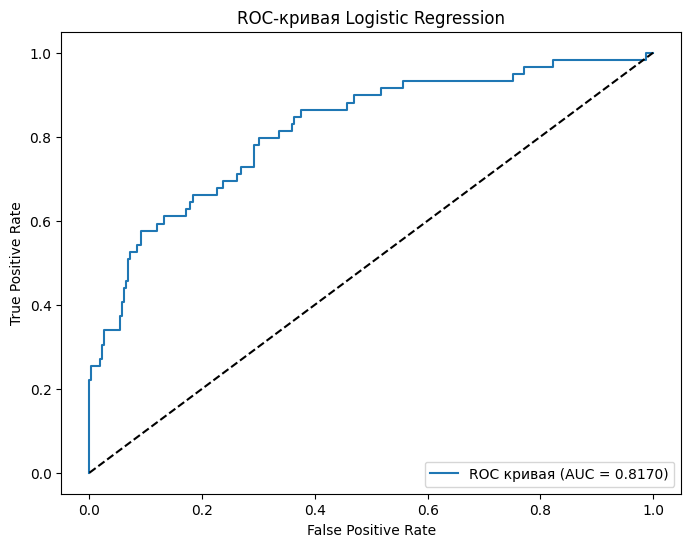

In [ ]:
# Построение ROC-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC кривая (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая Logistic Regression')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Получение и анализ коэффициентов модели
coefficients = pd.DataFrame({
'Признак': X.columns,
'Коэффициент': model.coef_[0]
})
coefficients = coefficients.sort_values(by='Коэффициент', ascending=False)
print("\nКоэффициенты модели:")
print(coefficients)


Коэффициенты модели:
                     Признак  Коэффициент
18              Overtime_new     0.784239
28   YearsSinceLastPromotion     0.565154
3             Department_new     0.558697
17        NumCompaniesWorked     0.548281
1         BusinessTravel_new     0.546447
14         MaritalStatus_new     0.409907
4           DistanceFromHome     0.282270
8                 Gender_new     0.271601
26            YearsAtCompany     0.241966
16               MonthlyRate     0.069366
20         PerformanceRating     0.063667
11                  JobLevel     0.043561
5                  Education     0.005089
6         EducationField_new     0.003897
9                 HourlyRate    -0.111923
2                  DailyRate    -0.175899
19         PercentSalaryHike    -0.221187
25           WorkLifeBalance    -0.237167
22          StockOptionLevel    -0.263156
24     TrainingTimesLastYear    -0.266106
12               JobRole_new    -0.296787
15             MonthlyIncome    -0.335209
27        Ye

**Вывод:**

Accuracy (Общая точность модели) Logistic Regression — 0,77. Модель верно классифицирует состояние сотрудника в 77% случаев.

Precision (Точность) — 0,38. Невысокое значение точности указывает на наличие ложноположительных прогнозов. 38% сотрудников, которых модель отнесла к группе риска, действительно планируют уволиться.

Recall (Полнота) — 0,66. Модель успешно выявляет 66% сотрудников, которые действительно собираются уволиться.

F1-score — 0,48. Данный показатель подтверждает, что модель не нашла оптимальный баланс между охватом «группы риска» и точностью прогноза в условиях сильно несбалансированной выборки. Вместо этого алгоритм продемонстрировал смещение в сторону максимального охвата сотрудников (Recall = 0,66) за счет снижения точности (Precision = 0,38).

Для логистической регрессии интерпретация строится на анализе коэффициентов модели. Предсказание вероятности увольнения: положительный коэффициент означает рост вероятности увольнения, а отрицательный — удержание сотрудника.

Факторы, сильнее всего влияющие на вероятность увольнения:

1. Over time (переработки): 0,784239. Это самый весомый фактор модели. Сверхурочная работа сильнее всего подталкивает сотрудников к увольнению.

2. Years since last promotion (количество лет с момента последнего повышения): 0,565154. Отсутствие карьерного роста. Если сотрудника давно не повышали, он начинает искать возможности за пределами компании.

3. Department (отдел): 0,558697. Вероятно, в конкретных отделах (часто это Research & Development или Sales) текучесть кадров выше, чем в среднем по компании.

4. Num сompanies worked (количество компаний, в которых работал сотрудник):  0,548281. Сотрудники, часто менявшие работу в прошлом, более склонны к уходу и сейчас.

5. Business travel (командировки): 0,546447. Частые командировки негативно сказываются на балансе работы и жизни. Модель показала, что частые поездки создают дополнительную нагрузку, повышая вероятность увольнения.

Факторы удержания сотрудников в компании:

1. Total working years (общий стаж): - 0,548842. Опытные сотрудники увольняются значительно реже.

2. Years with current manager (количество лет работы с текущим руководителем): - 0,548417. Самый сильный фактор удержания. Хорошие отношения с непосредственным руководителем и стабильность в подчинении очень важны.

3. Job satisfaction (удовлетворенность работой): - 0,494034. Интерес к работе, задачам снижает риск увольнения.

4. Environment satisfaction (уровень удовлетворенности рабочей средой): - 0,436191. Психологический, физический, организационный комфорт в компании значимо снижает риск увольнения.

5. Relationship satisfaction (удовлетворенность отношениями): -0,394732. Высокая удовлетворенность взаимоотношениями внутри коллектива снижает риск увольнения персонала.

Сотрудники, находящиеся в группе повышенного риска увольнения:
- работают сверхурочно;
- давно не продвигались по карьерной лестнице;
- работают в отделах с высокой текучестью кадров;
- сменили большое количество работодателей до IBM;
- часто ездят в командировки;
- имеют небольшой рабочий стаж (молодые специалисты);
- у которых сменился текущий руководитель;
- неудовлетворены рабочей средой и работой;
- неудовлетворены взаимоотношениями внутри коллектива;
- холост / не замужем;
- живут далеко от офиса;
- недовольны уровнем заработной платы;
- не имеют акции компании (StockOptionLevel = 0).

Логистическая регрессия требует независимости признаков: коррелирующие переменные снижают надёжность модели. Алгоритму необходимо много данных для обучения, и он эффективен только при линейной разделимости классов, т.к. строит линейную границу решения (https://practicum.yandex.ru/blog/logisticheskaya-regressiya-v-mashinnom-obucheni/).

Данная модель обязана своей надёжностью большому количеству данных, которые помогают ей выучить по-настоящему важные и устойчивые закономерности, а не просто "зазубрить". Чем больше данных у неё есть, тем правильнее результат.

Чувствительна к мультиколлинеарности, т.е. признаки коррелируют между собой (например, Monthly income, Job level, Total working years). Модель может некорректно распределить веса между ними.

Пропущенными факторами могут быть:
- формат работы: удаленно, на месте работодателя, гибрид;
- личные причины: переезд, семейные обстоятельства, состояние здоровья;
- причины переработок: большой объем работы или некомпетентное управление кадрами;
- уровень заработной платы на рынке труда, наличие вакансий.











**Random Forest**

Формирование признаков и целевой переменной

In [ ]:
df_new.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_new',
       'Overtime_new', 'Gender_new', 'BusinessTravel_new', 'Department_new',
       'EducationField_new', 'JobRole_new', 'MaritalStatus_new'],
      dtype='object')

In [ ]:
# Признаки
X = df_new[['Age', 'BusinessTravel_new', 'DailyRate', 'Department_new','DistanceFromHome',
        'Education', 'EducationField_new', 'EnvironmentSatisfaction', 'Gender_new', 'HourlyRate',
        'JobInvolvement', 'JobLevel', 'JobRole_new', 'JobSatisfaction', 'MaritalStatus_new',
        'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Overtime_new', 'PercentSalaryHike',
        'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
        'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole','YearsSinceLastPromotion', 'YearsWithCurrManager'
      ]]

# Целевая переменная (0 или 1)
y = df_new['Attrition_new']

In [ ]:
print(X.head().T)

                              0      1     2      3      4
Age                          41     49    37     33     27
BusinessTravel_new            1      2     1      2      1
DailyRate                  1102    279  1373   1392    591
Department_new                3      2     2      2      2
DistanceFromHome              1      8     2      3      2
Education                     2      1     2      4      1
EducationField_new            2      2     5      2      4
EnvironmentSatisfaction       2      3     4      4      1
Gender_new                    0      1     1      0      1
HourlyRate                   94     61    92     56     40
JobInvolvement                3      2     2      3      3
JobLevel                      2      2     1      1      1
JobRole_new                   8      7     3      7      3
JobSatisfaction               4      2     3      3      2
MaritalStatus_new             3      2     3      2      2
MonthlyIncome              5993   5130  2090   2909   34

In [ ]:
print(y)

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition_new, Length: 1470, dtype: int64


Разделение на обучающую и тестовую выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

In [ ]:
print(X_train.head().T)

                          853    435    587   1170   159 
Age                         19     33     52    27     34
BusinessTravel_new           1      1      1     2      2
DailyRate                  645   1277   1325   591    303
Department_new               2      2      2     2      3
DistanceFromHome             9     15     11     2      2
Education                    2      1      4     3      4
EducationField_new           2      4      2     4      3
EnvironmentSatisfaction      3      2      4     4      3
Gender_new                   1      1      0     1      0
HourlyRate                  54     56     82    87     75
JobInvolvement               3      3      3     3      3
JobLevel                     1      3      2     1      1
JobRole_new                  7      4      3     7      9
JobSatisfaction              1      3      3     4      3
MaritalStatus_new            3      2      2     3      2
MonthlyIncome             2552  13610   3149  2580   2231
MonthlyRate   

In [ ]:
print(X_test.head().T)

                           397    832    483    456    1342
Age                          25     37     35     31     34
BusinessTravel_new            1      1      1      1      1
DailyRate                   891    367    538    688   1480
Department_new                3      2      2      3      3
DistanceFromHome              4     25     25      7      4
Education                     2      2      2      3      3
EducationField_new            2      4      5      2      2
EnvironmentSatisfaction       2      3      1      3      3
Gender_new                    0      0      1      1      1
HourlyRate                   99     52     54     44     64
JobInvolvement                2      2      2      2      3
JobLevel                      2      2      2      3      3
JobRole_new                   8      1      3      4      8
JobSatisfaction               4      4      4      4      4
MaritalStatus_new             3      1      3      1      2
MonthlyIncome              4487   5731  

In [ ]:
y_train

,Attrition_new
853,0
435,1
587,0
1170,0
159,0
...,...
365,0
963,0
734,0
1315,0


In [ ]:
y_test

,Attrition_new
397,0
832,0
483,0
456,0
1342,0
...,...
416,0
1098,0
514,1
1442,1


Создание и обучение модели Random Forest, оценка её эффективности

In [ ]:
# Использован специализированный алгоритм - BalancedRandomForestClassifier из библиотеки imblearn для работы с несбалансированными данными

# Инициализация и обучение модели
rf_model = BalancedRandomForestClassifier(
    n_estimators = 100,
    sampling_strategy = 'all',
    replacement = True,
    random_state = 42
)

rf_model.fit(X_train, y_train)

BalancedRandomForestClassifier(random_state=42)

In [ ]:
# Прогнозирование на тестовой выборке
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
# Оценка качества модели
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели: {accuracy:.4f}')

Точность модели: 0.8141


In [ ]:
# Детальный отчёт о качестве классификации
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred))


Отчет по классификации:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       370
           1       0.43      0.46      0.45        71

    accuracy                           0.81       441
   macro avg       0.66      0.67      0.67       441
weighted avg       0.82      0.81      0.82       441



In [ ]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print('\nМатрица ошибок:')
print(cm)


Матрица ошибок:
[[326  44]
 [ 38  33]]


In [ ]:
# ROC-кривая и значение AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC AUC: {roc_auc:.4f}")


ROC AUC: 0.7557


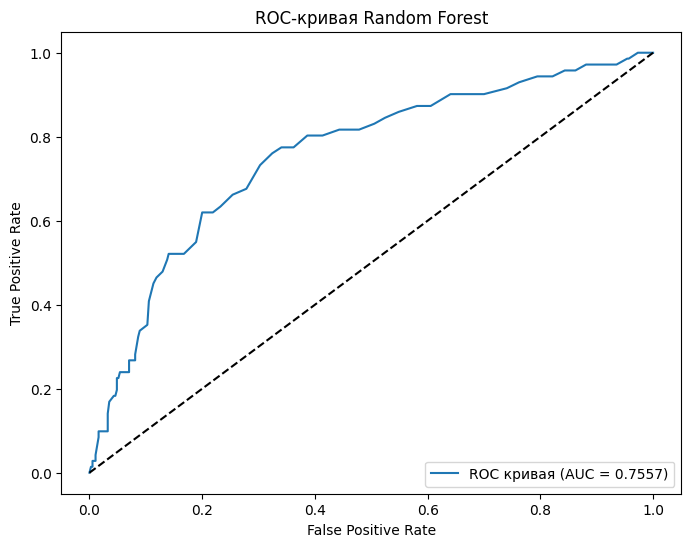

In [ ]:
# Построение ROC-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC кривая (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая Random Forest')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Получение оценок важности признаков
feature_importance = pd.DataFrame({
'feature': X.columns,
'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print('\nВажность признаков:')
print(feature_importance)


Важность признаков:
                     feature  importance
15             MonthlyIncome    0.076368
0                        Age    0.069707
2                  DailyRate    0.051842
26            YearsAtCompany    0.051717
23         TotalWorkingYears    0.050971
9                 HourlyRate    0.048913
29      YearsWithCurrManager    0.045943
4           DistanceFromHome    0.045260
16               MonthlyRate    0.045044
22          StockOptionLevel    0.042931
17        NumCompaniesWorked    0.038922
18              Overtime_new    0.037538
12               JobRole_new    0.033776
27        YearsInCurrentRole    0.031734
19         PercentSalaryHike    0.029169
21  RelationshipSatisfaction    0.027959
7    EnvironmentSatisfaction    0.027131
10            JobInvolvement    0.025757
13           JobSatisfaction    0.025526
25           WorkLifeBalance    0.024539
28   YearsSinceLastPromotion    0.021975
24     TrainingTimesLastYear    0.021921
5                  Education    0.02

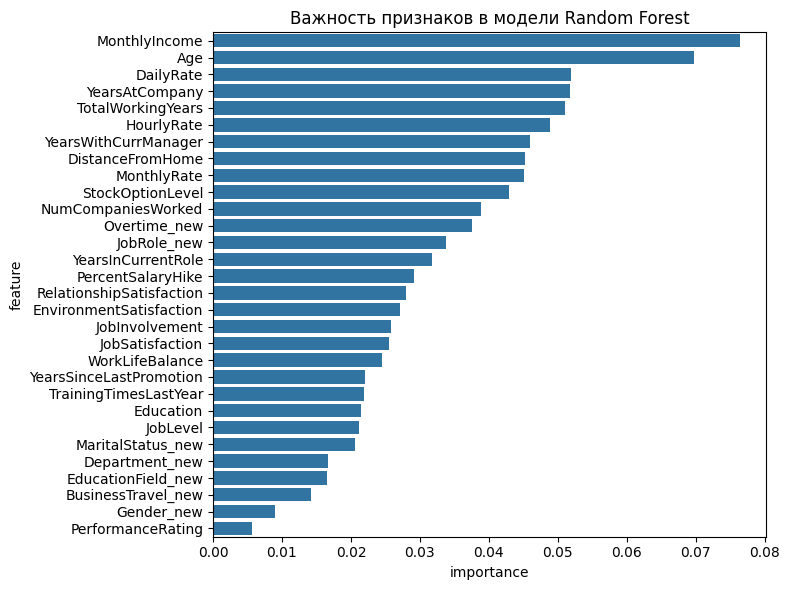

In [ ]:
# Визуализация
plt.figure(figsize = (8, 6))
sns.barplot(x = 'importance', y='feature', data = feature_importance)
plt.title('Важность признаков в модели Random Forest')
plt.tight_layout()
plt.show()

**Вывод:**

Accuracy (Общая точность модели) Random Forest — 0,81. Модель верно классифицирует состояние сотрудника в 81% случаев.

Precision (Точность) — 0,43. Относительно невысокое значение точности означает наличие ложноположительных прогнозов. 43% сотрудников, которых модель отнесла к группе риска, действительно планируют уволиться.

Recall (Полнота) — 0,46. Модель успешно идентифицирует 46% сотрудников, которые действительно намерены уволиться.

F1-score — 0,45. Значение метрики свидетельствует о несбалансированности и низком общем качестве предсказаний модели. Несмотря на относительно высокую общую точность (Accuracy = 0,81), гармоническое среднее между Precision и Recall находится на низком уровне.

Для модели Random Forest интерпретация строится на анализе показателей feature importance.

Факторы, сильнее всего влияющие на вероятность увольнения:

1. Monthly income (ежемесячный доход): 0,076368 (в связке с DailyRate = 0,051842, HourlyRate = 0,048913, MonthlyRate = 0,045044). С увеличением заработной платы вероятность увольнения снижается.

2. Age (возраст): 0,069707. Молодые сотрудники увольняются чаще ради достойной заработной платы, карьерного роста, нового опыта.

3. Years at company (количество лет в компании): 0,051717. Чем больше сотрудник проработал в компании, тем меньше вероятность его увольнения.

4. Total working years (общий стаж): 0,050971. Опытные сотрудники увольняются значительно реже.

5. Years with current manager (количество лет работы с текущим руководителем): 0,045943. Чем больше сотрудник проработал с текущим руководителем, тем меньше вероятность увольнения.

Сотрудники, находящиеся в группе повышенного риска увольнения:
- недовольны уровнем заработной платы;
- молодые специалисты;
- недолго работают в компании IBM;
- имеют небольшой рабочий стаж;
- у которых сменился текущий руководитель;
- живут далеко от офиса;
- не имеют акции компании (StockOptionLevel = 0);
- сменили большое количество работодателей до IBM;
- работают сверхурочно;
- чаще всего увольняются с определенных должностей.

Метод случайных лесов имеет следующие ограничения (https://sky.pro/wiki/python/metod-sluchajnogo-lesa-osnovy-i-primery/):
- вычислительная сложность — обучение и применение множества деревьев требует значительных ресурсов;
- "чёрный ящик" — несмотря на возможность анализа важности признаков, общая интерпретируемость модели ниже, чем у одиночного дерева решений. Не показывает направленности, например, для возраста сотрудников (увольняются молодые сотрудники или наоборот);
- сложности с экстраполяцией — модель плохо предсказывает значения вне диапазона обучающих данных;
- смещение в пользу категориальных признаков с большим количеством уникальных значений;
- избыточность деревьев — после определенного количества деревьев добавление новых не улучшает качество предсказаний.

Пропущенными факторами могут быть:
- формат работы: удаленно, на месте работодателя, гибрид;
- личные причины: переезд, семейные обстоятельства, состояние здоровья;
- причины переработок: большой объем работы или некомпетентное управление кадрами;
- уровень заработной платы на рынке труда, наличие вакансий.


**Общий вывод по прогнозным моделям**

При дисбалансе классов модель может смещаться в сторону доминирующего класса, когда переменных одной категории сильно больше другой: например, увольняющихся мало (16,12%), модель склонна чаще ошибаться в сторону "не уволится", если не настроены веса классов.

Основные проблемы:

- cмещение модели: алгоритмы склонны игнорировать редкие классы;

- низкая чувствительность (recall) для меньшинства;

- искажение метрик: стандартные метрики, такие как accuracy, могут быть обманчивыми.

Были применены следующие подходы для борьбы с дисбалансом классов:

**Для Logistic Regression:**

- настройка весов классов (class_weight='balanced'): **F1-score по классу 1 = 0,46 / Precision = 0,36 / Recall = 0,66**;  
       
- генерация синтетических данных (SMOTE): **F1-score по классу 1 = 0,48 / Precision = 0,38 / Recall = 0,66**;

- undersampling (уменьшение доминирующего класса): **F1-score по классу 1 = 0,44 / Precision = 0,33 / Recall = 0,63**.

**Вывод:**
В итоге для построения модели логистической регресии был выбран популярный алгоритм машинного обучения, который решает проблему дисбаланса данных, SMOTE (F1-score по классу 1 = 0,48). Логистическая регрессия очень чувствительна к нехватке данных. SMOTE добавил новые синтетические примеры увольняющихся сотрудников, заполнив пустоты в пространстве признаков. Точность (Precision = 0,38) выросла по сравнению с другими методами: модель стала делать меньше ложных срабатываний. При этом полнота (Recall = 0,66) осталась на высоком уровне: модель по-прежнему стабильно находит 66% тех, кто действительно планирует уволиться.

**Для Random Forest:**

- настройка весов классов (class_weight='balanced'): **F1-score по классу 1 = 0,24 / Precision = 0,43 / Recall = 0,17**;       

- генерация синтетических данных (SMOTE): **F1-score по классу 1 = 0,33 / Precision = 0,36 / Recall = 0,30**;      

- undersampling (уменьшение доминирующего класса): **F1-score по классу 1 = 0,43 / Precision = 0,32 / Recall = 0,63**;

- специализированный алгоритм BalancedRandomForestClassifier: **F1-score по классу 1 = 0,45 / Precision = 0,43 / Recall = 0,46**.

**Вывод:**
В итоге для построения модели случайного леса был выбран специализированный алгоритм BalancedRandomForestClassifier, разработанный для борьбы с сильным дисбалансом классов в обучающей выборке (F1-score по классу 1 = 0,45). В отличие от обычного ресэмплинга всего датасета, этот алгоритм балансирует данные внутри каждого дерева отдельно. Каждое дерево учится на своей равной пропорции классов, но весь ансамбль в совокупности видит все доступные данные. Модель получила баланс между точностью (Precision = 0,43) и полнотой (Recall = 0,46).

**Общий вывод:**
В данном случае эффективна модель логистической регрессии, так как она, в отличие от модели случайного леса:

-  успешно выявляет 66% сотрудников, которые действительно собираются уволиться;

- имеет более высокий показатель F1-score (0,48 против 0,45), что критически важно в условиях дисбаланса данных.

Коэффициенты данной модели позволили определить основные факторы увольнения сотрудников: переработки, отсутствие карьерного роста, работа в отделах с высокой текучестью кадров, смена большого количества работодателей до IBM, частые поездки в командировки.


# Выводы и Рекомендации

**Выводы:**

Анализ данных на основе датасета «IBM HR Analytics Employee Attrition & Performance» выявил основные ключевые факторы, коррелирующие с увольнением сотрудников.

• Over time (переработки). Самый ключевой фактор. Сверхурочная работа сильнее всего подталкивает сотрудников к увольнению. Постоянное перенапряжение приводит к выгоранию сотрудников и снижению их мотивации.

• Marital status (семейное положение). Одинокие сотрудники (single) увольняются чаще, чем состоящие в браке или разведенные. Это объясняется отсутствием семейных обязательств, что делает их более мобильными и готовыми к смене работы ради карьеры или смене обстановки.

• Total working years (общий стаж). Опытные сотрудники увольняются значительно реже. Чем меньше стаж, тем больше вероятность увольнения.

• Age (возраст). Молодые сотрудники (до 31 года) увольняются чаще. Скорее всего это стажеры, либо временные сотрудники, которые изначально не планируют оставаться в компании на длительный срок. Это указывает на то, что компания является для них «стартовой площадкой».

• Monthly income (месячный доход). С увеличением заработной платы вероятность увольнения снижается. Высокая заработная плата эффективно компенсирует другие негативные факторы.

• Years with current manager (количество лет работы с текущим руководителем). Количество увольнений снижается с увеличением срока совместной работы. Стабильность отношений с руководителем напрямую снижает риск увольнения.

• Stock option level (уровень опционов). Чем меньше акций у сотрудника (или их нет), тем больше вероятность увольнения. Не имея накопленных долгосрочных активов в компании, сотрудники легче принимают решение об уходе, в то время как наличие акций удерживает ключевых сотрудников.


Согласно прогнозным моделям Logistic Regression и Random Forest в группе повышенного риска увольнения находятся сотрудники, которые:
- работают сверхурочно;
- давно не продвигались по карьерной лестнице;
- работают в отделах с высокой текучестью кадров;
- сменили большое количество работодателей до IBM;
- часто ездят в командировки;
- имеют небольшой рабочий стаж;
- молодые специалисты;
- недовольны уровнем заработной платы.













**Рекомендации:**

Для снижения уровня увольнений сотрудников и оптимизации HR-процессов предлагаются следующие меры:

**Высшему руководству:**

• внедрить систему контроля нагрузки для предотвращения системных переработок;

• пересмотреть систему оплаты труда на предмет справедливости и конкурентоспособности;

• развивать программу опционов;

• улучшить взаимодействие с руководителями отделов.

**HR-директору и HR-менеджерам (Human Resources):**

• усовершенствовать процесс адаптации сотрудников на начальном этапе;

• упростить процесс карьерного роста и внутренней мобильности;

• обеспечить регулярный аудит кадровых показателей;

• получать регулярную обратную связь с помощью HR-исследований;

• ввести в практику финальное интервью.

**Руководителям отделов (Sales, Research & Development, Human Resources):**

• поддерживать открытый диалог с командой;

• обучать менеджеров лидерству и коммуникациям;

• учитывать личную мотивацию сотрудников;

• рационально распределять своё время и ресурсы;

• развивать управленческие навыки.

**Сотрудникам компании:**

• использовать возможности кадровых перемещений внутри компании;

• проявлять инициативу в профессиональном развитии;

• информировать о перегрузках и грамотно управлять собственной нагрузкой (тайм-менеджмент);

• участвовать в конструктивном диалоге с руководством.

**Заключение:**

В ходе выполнения дипломной работы было реализовано комплексное исследование датасета «IBM HR Analytics Employee Attrition & Performance» с помощью общепринятого набора процедур, а именно:

• начальное исследование (Discovery);

• подготовка и очистка данных (Data Wrangling);

• разведочный анализ (Exploratory Data Analysis, EDA);

• проверка статистических гипотез;

• подготовка, построение и оценка прогнозных моделей;

• формулирование аналитических выводов;

• разработка практических рекомендаций.

Подключены библиотеки, источник данных, изучены структура и состав набора данных для понимания природы признаков и типов переменных.

Выполнены очистка и подготовка данных (обработка пропусков, кодирование категориальных признаков), что обеспечило их пригодность для дальнейшего статистического анализа.

Анализ данных:

•  проведен комплексный статистический и визуальный анализ данных для выявления закономерностей распределения и различий в характеристиках между целевыми группами;

• проведен корреляционный анализ для выявления связи между признаками;

• сформулированы и математически подтверждены статистические гипотезы о влиянии возраста сотрудников и сверхурочной работы на отток персонала с применением соответствующих критериев;

• разработаны и обучены прогнозные модели (Logistic Regression, Random Forest) для оценки вероятности увольнения, проведена оценка качества построенных моделей, выявлены ключевые факторы оттока и интерпретировано их влияние на бизнес-процессы.

Сделаны выводы и даны рекомендации стейкхолдерам по снижению уровня увольнений сотрудников и оптимизации HR-процессов.

Результаты и визуализации, полученные в ходе дипломной работы, являются ценной информацией для руководителей и HR-специалистов, стремящихся понять и минимизировать текучесть кадров в компании. Данный проект демонстрирует возможности анализа данных и машинного обучения в решении реальных бизнес-задач.





